# Credit Scoring Model - 01: Data Loading and Review

**Objective:** Load the dataset, perform initial review, and understand the structure.

**Dataset:** 150,000 anonymized borrower records with demographic, credit utilization, payment history, and financial metrics.

**Target Variable:** `SeriousDlqin2yrs` — Predicts the likelihood of a borrower experiencing financial distress (90+ days past due) within 2 years.

---

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from eda_utils import load_data, basic_info

# Enable inline plotting for Jupyter
%matplotlib inline

# Configure visualization settings
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

# Output directory for saved figures
OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## 1. Load Dataset

In [2]:
df = load_data('../data/cs-training.csv')

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\nFirst 5 rows:')
df.head()

Dataset loaded: 150,000 rows × 11 columns

First 5 rows:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Column Descriptions

In [3]:
column_descriptions = {
    'SeriousDlqin2yrs': 'TARGET: 1 = 90+ days past due in 2 years, 0 = No default',
    'RevolvingUtilizationOfUnsecuredLines': 'Total balance on credit cards / credit limits (ratio)',
    'age': 'Age of borrower in years',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Times borrower was 30-59 days past due (not worse) in last 2 years',
    'DebtRatio': 'Monthly debt payments / monthly gross income',
    'MonthlyIncome': 'Monthly income in USD',
    'NumberOfOpenCreditLinesAndLoans': 'Number of open loans and lines of credit',
    'NumberOfTimes90DaysLate': 'Times borrower was 90+ days past due',
    'NumberRealEstateLoansOrLines': 'Number of mortgage and real estate loans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Times borrower was 60-89 days past due (not worse) in last 2 years',
    'NumberOfDependents': 'Number of dependents in family (excluding borrower)'
}

desc_df = pd.DataFrame(list(column_descriptions.items()), columns=['Column', 'Description'])
print('Column Descriptions:')
print('=' * 80)
for _, row in desc_df.iterrows():
    print(f'  {row["Column"]:<45} {row["Description"]}')

Column Descriptions:
  SeriousDlqin2yrs                              TARGET: 1 = 90+ days past due in 2 years, 0 = No default
  RevolvingUtilizationOfUnsecuredLines          Total balance on credit cards / credit limits (ratio)
  age                                           Age of borrower in years
  NumberOfTime30-59DaysPastDueNotWorse          Times borrower was 30-59 days past due (not worse) in last 2 years
  DebtRatio                                     Monthly debt payments / monthly gross income
  MonthlyIncome                                 Monthly income in USD
  NumberOfOpenCreditLinesAndLoans               Number of open loans and lines of credit
  NumberOfTimes90DaysLate                       Times borrower was 90+ days past due
  NumberRealEstateLoansOrLines                  Number of mortgage and real estate loans
  NumberOfTime60-89DaysPastDueNotWorse          Times borrower was 60-89 days past due (not worse) in last 2 years
  NumberOfDependents                       

## 3. Dataset Overview

In [4]:
basic_info(df)

DATASET OVERVIEW
Dataset Shape: 150,000 rows × 11 columns
Memory Usage: 12.59 MB

DATA TYPES
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

MISSING VALUES SUMMARY
                    Missing_Count  Percentage
MonthlyIncome               29731       19.82
NumberOfDependents           3924        2.62

NUMERICAL FEATURES STATISTICS
       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines            age  \
count     150000.000000                         150000.000000  150000.000000   
mean        

## 4. Target Variable Distribution

✓ Figure saved: ../outputs/01_target_distribution.png


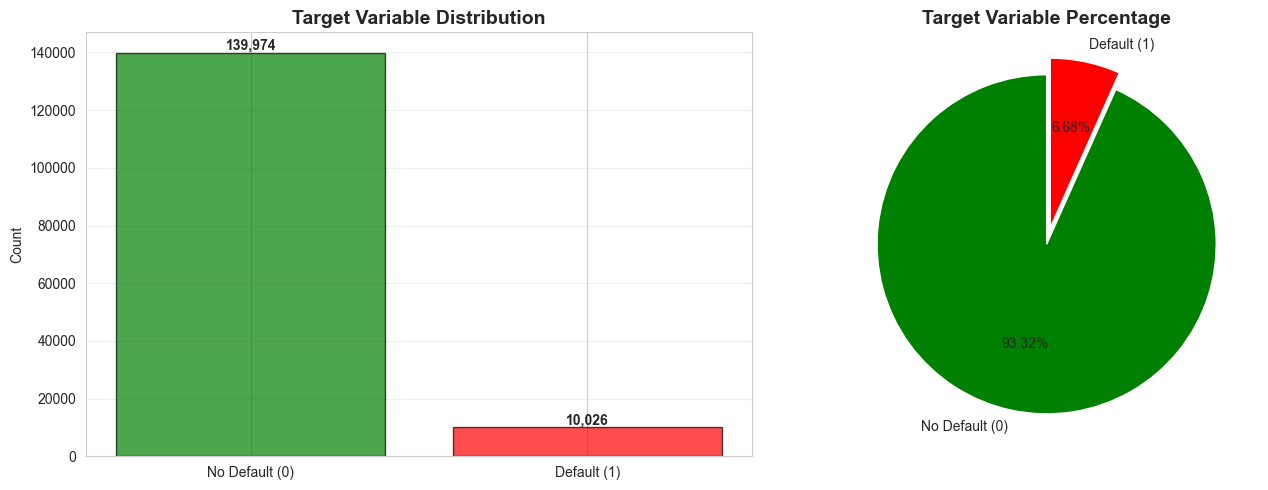


Class Imbalance Ratio: 1:13.96
⚠️  Note: Significant class imbalance detected. Consider SMOTE, class weights, or stratified sampling.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = df['SeriousDlqin2yrs'].value_counts()
axes[0].bar(['No Default (0)', 'Default (1)'], target_counts.values,
            color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

target_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100
axes[1].pie(target_pct.values, labels=['No Default (0)', 'Default (1)'],
            autopct='%1.2f%%', colors=['green', 'red'], startangle=90,
            explode=(0, 0.1))
axes[1].set_title('Target Variable Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/01_target_distribution.png', dpi=150, bbox_inches='tight')
print(f'✓ Figure saved: {OUTPUT_DIR}/01_target_distribution.png')
plt.show()
print(f'\nClass Imbalance Ratio: 1:{target_counts[0]/target_counts[1]:.2f}')
print('⚠️  Note: Significant class imbalance detected. Consider SMOTE, class weights, or stratified sampling.')

## 5. Save Dataset Summary

In [6]:
summary = {
    'Total Records': df.shape[0],
    'Total Features': df.shape[1],
    'Default Rate (%)': round(df['SeriousDlqin2yrs'].mean() * 100, 2),
    'Non-Default Count': int(target_counts[0]),
    'Default Count': int(target_counts[1]),
    'Class Imbalance Ratio': f'1:{target_counts[0]/target_counts[1]:.2f}'
}

print('Dataset Summary:')
print('=' * 40)
for k, v in summary.items():
    print(f'  {k:<30} {v}')

print('\n✓ Notebook 01 complete. Figures saved to outputs/')

Dataset Summary:
  Total Records                  150000
  Total Features                 11
  Default Rate (%)               6.68
  Non-Default Count              139974
  Default Count                  10026
  Class Imbalance Ratio          1:13.96

✓ Notebook 01 complete. Figures saved to outputs/
